In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 22 — Smooth flows, coordinate changes and invertible networks

Measured Iris feature pairs transformed by a chosen invertible map; the flow itself is a mathematical construction.

This is an executed reference, not a learner assessment. Read the lesson and predict the results before running. All code is inspectable in `src/shape_lab/physics`. No model or dataset downloads occur.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
STAGE=22
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd()
while not (ROOT/'pyproject.toml').exists() and ROOT.parent!=ROOT:ROOT=ROOT.parent
if not (ROOT/'pyproject.toml').exists():raise RuntimeError('Open this notebook within the extracted project.')
sys.path.insert(0,str(ROOT/'src'))
from shape_lab.physics import classical as c, constraints as con, gradients as grad, operators as op
hahn=pd.read_csv(ROOT/'data/physics/hahn1_excerpt.csv')
hahn_manifest=json.loads((ROOT/'data/physics/manifest.json').read_text())
OUT=ROOT/'physics/reports'/f'{STAGE:02d}'
OUT.mkdir(parents=True,exist_ok=True)
def save_report(result):
    result={'stage':STAGE,'role':'executed teaching experiment; not learner assessment',**result}
    result['source_review_date']='2026-09-20'
    (OUT/'results.json').write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
    print(json.dumps(result,indent=2))
def finish_figure(name):
    plt.tight_layout();plt.savefig(OUT/f'{name}.png',dpi=140,bbox_inches='tight');plt.show();plt.close()
print('Course:', ROOT.name, '| stage:', STAGE)


Course: course | stage: 22


## Local is not global
Reject a time beyond blow-up; then test reversibility on the common valid domain.

In [3]:
x=np.array([-.3,.2,.6]);roundtrip=c.quadratic_flow(c.quadratic_flow(x,.4),-.4)
np.testing.assert_allclose(roundtrip,x)
try:c.quadratic_flow(2.,.6)
except ValueError as error:print('Expected domain failure:',error)
else:raise AssertionError('Blow-up was incorrectly accepted.')

Expected domain failure: Time crosses a finite-time singularity: require 1-t*x>0.


## An explicit invertible map on observed features
The observations are real; the transformation is chosen by us. Standardization is exploratory, not a predictive split.

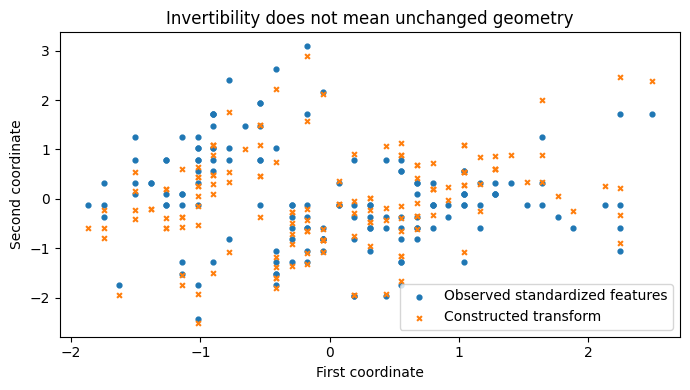

{
  "stage": 22,
  "role": "executed teaching experiment; not learner assessment",
  "data_kind": "observed Iris features under constructed invertible coupling",
  "observations": 150,
  "roundtrip_max_abs_error": 4.440892098500626e-16,
  "logdet_min": -0.1907192623181259,
  "logdet_max": 0.19728007824199406,
  "density_model_trained": false,
  "unsupported": "Not a biological growth flow or preservation of Euclidean distances.",
  "source_review_date": "2026-09-20"
}


In [4]:
iris=pd.read_csv(ROOT/'data/raw/iris.csv')
X=iris[['sepal_length_cm','sepal_width_cm']].to_numpy();X=(X-X.mean(axis=0))/X.std(axis=0)
Y,logdet=c.coupling(X);error=float(np.max(np.abs(c.coupling_inverse(Y)-X)))
assert error<1e-12
plt.figure(figsize=(7,4));plt.scatter(X[:,0],X[:,1],s=12,label='Observed standardized features');plt.scatter(Y[:,0],Y[:,1],s=12,marker='x',label='Constructed transform');plt.legend();plt.xlabel('First coordinate');plt.ylabel('Second coordinate');plt.title('Invertibility does not mean unchanged geometry');finish_figure('coupling')
save_report({'data_kind':'observed Iris features under constructed invertible coupling','observations':len(X),'roundtrip_max_abs_error':error,'logdet_min':float(logdet.min()),'logdet_max':float(logdet.max()),'density_model_trained':False,'unsupported':'Not a biological growth flow or preservation of Euclidean distances.'})

## Independent explanation

Write the data origin, one supported conclusion and one unsupported conclusion. Change one parameter while preserving the comparison horizon or unit. Save your answer separately; successful reference execution is not proof that you understand the result.